In [2]:
import numpy as np
import matplotlib.pyplot as plt
import scipy as scipy
def single_failure_sim(p):
   r = np.random.random()
   if r <= p:
    return 'Fail'
   else:
    return 'Success'

def fleet_sim(n,p):
  failed = 0
  for i in range(n):
    result = (single_failure_sim(p))
    if result == 'Fail': # Corrected from 'Failed' to 'Fail'
      failed +=1
  return failed

print(f"Number of failures in a fleet of 100 with 10% failure rate: {fleet_sim(100,0.1)}")

Number of failures in a fleet of 100 with 10% failure rate: 11


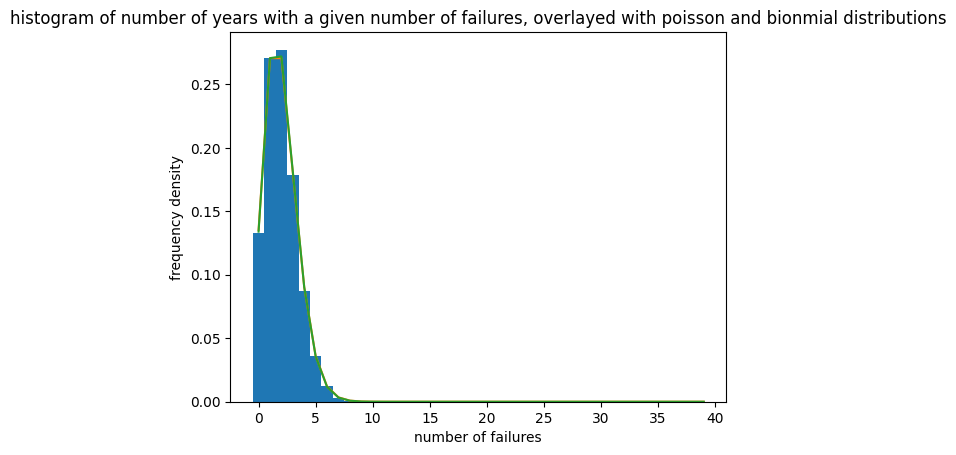

In [5]:
def multiple_years_sim(y,n,p):
  count = []
  for i in range(y):
    loss = fleet_sim(n,p)
    count.append(loss)
  return count

years = 10000
n = 200
p = 0.01
fleet = multiple_years_sim(years,n,p)
bins = np.arange(min(fleet)-0.5,max(fleet)+2,1)
x = np.arange(0,40,1)
y = scipy.stats.poisson.pmf(x,p*n)
y2 = scipy.stats.binom.pmf(x,200,p)
plt.hist(fleet,bins = bins, density = True,label = 'simulation')
plt.plot(x,y,label = 'poisson')
plt.plot(x,y2,label = 'binomial')
plt.legend
plt.xlabel('number of failures')
plt.ylabel('frequency density')
plt.title('histogram of number of years with a given number of failures, overlayed with poisson and bionmial distributions')
plt.show()